URL Anomaly Detection Results:

                                                  URL  URL_Length  Dots  \
0                                  https://google.com          18     1   
1                                  https://amazon.com          18     1   
2                                  https://github.com          18     1   
3                               https://microsoft.com          21     1   
4                               https://wikipedia.org          21     1   
5                                   https://apple.com          17     1   
6                                 https://youtube.com          19     1   
7                                https://facebook.com          20     1   
8                    http://secure-login123456789.xyz          32     1   
9               http://free-prize-win-2024-999999.com          37     1   
10  http://very-long-suspicious-url-login-account-...          55     1   
11          http://bank-verify-security-987654321.xyz          41   

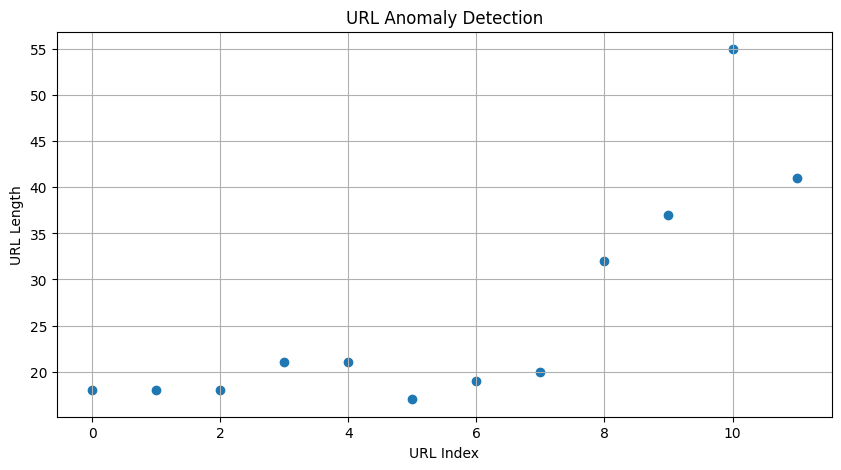

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

# Sample URL dataset
data = pd.DataFrame({
    "URL": [
        "https://google.com",
        "https://amazon.com",
        "https://github.com",
        "https://microsoft.com",
        "https://wikipedia.org",
        "https://apple.com",
        "https://youtube.com",
        "https://facebook.com",
        "http://secure-login123456789.xyz",
        "http://free-prize-win-2024-999999.com",
        "http://very-long-suspicious-url-login-account-12345.xyz",
        "http://bank-verify-security-987654321.xyz"
    ]
})

# Feature Engineering
data["URL_Length"] = data["URL"].apply(len)

data["Dots"] = data["URL"].apply(
    lambda x: x.count(".")
)

data["Hyphens"] = data["URL"].apply(
    lambda x: x.count("-")
)

data["Digits"] = data["URL"].apply(
    lambda x: sum(c.isdigit() for c in x)
)

data["Special_Characters"] = data["URL"].apply(
    lambda x: sum(
        not c.isalnum() and c not in ":/."
        for c in x
    )
)

data["HTTPS"] = data["URL"].apply(
    lambda x: 1 if x.startswith("https") else 0
)

# Select features
features = [
    "URL_Length",
    "Dots",
    "Hyphens",
    "Digits",
    "Special_Characters",
    "HTTPS"
]

X = data[features]

# Isolation Forest
model = IsolationForest(
    contamination=0.25,
    random_state=42
)

# Detect anomalies
data["Prediction"] = model.fit_predict(X)

# Convert prediction to labels
data["Status"] = data["Prediction"].apply(
    lambda x: "Anomaly" if x == -1 else "Normal"
)

# Display results
print("URL Anomaly Detection Results:\n")

print(
    data[
        ["URL", "URL_Length", "Dots", "Hyphens",
         "Digits", "Status"]
    ]
)

# Display anomalous URLs
print("\nDetected Anomalous URLs:")

print(
    data[data["Status"] == "Anomaly"]["URL"]
)

# Visualization
plt.figure(figsize=(10, 5))

plt.scatter(
    data.index,
    data["URL_Length"]
)

plt.xlabel("URL Index")
plt.ylabel("URL Length")
plt.title("URL Anomaly Detection")
plt.grid(True)
plt.show()